# Cutoff Ratio Dashboard

- Notebook: `/home/silong/codex/antibiotics/antibiotic_benchmark/notebooks/cutoff.ipynb`
- Data: `/home/silong/codex/antibiotics/antibiotic_benchmark/datasets/data_pos_ratio.csv`

This notebook visualizes ratio(`value >= threshold`) across `train / val / test` splits.

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

csv_path = Path(r"/home/silong/codex/antibiotics/antibiotic_benchmark/datasets/data_pos_ratio.csv")
df = pd.read_csv(csv_path)
df = df.sort_values(["genus", "split", "threshold"]).reset_index(drop=True)

print("csv:", csv_path)
print("shape:", df.shape)
print("columns:", list(df.columns))
display(df.head(10))


csv: /home/silong/codex/antibiotics/antibiotic_benchmark/datasets/data_pos_ratio.csv
shape: (360, 5)
columns: ['genus', 'split', 'n_samples', 'threshold', 'pos_ratio_ge']


,genus,split,n_samples,threshold,pos_ratio_ge
0,Acinetobacter,test,1104,2.0,0.863225
1,Acinetobacter,test,1104,4.0,0.803442
2,Acinetobacter,test,1104,6.0,0.737319
3,Acinetobacter,test,1104,8.0,0.718297
4,Acinetobacter,test,1104,16.0,0.606884
5,Acinetobacter,test,1104,32.0,0.511775
6,Acinetobacter,test,1104,64.0,0.341486
7,Acinetobacter,test,1104,128.0,0.203804
8,Acinetobacter,train,9058,2.0,0.868183
9,Acinetobacter,train,9058,4.0,0.798962


## Split-Level Overview

,split,threshold,pos_ratio_ge
0,test,2.0,0.859506
1,test,4.0,0.810788
2,test,6.0,0.774105
3,test,8.0,0.743447
4,test,16.0,0.664589
5,test,32.0,0.528352
6,test,64.0,0.270952
7,test,128.0,0.150067
8,train,2.0,0.858248
9,train,4.0,0.807823


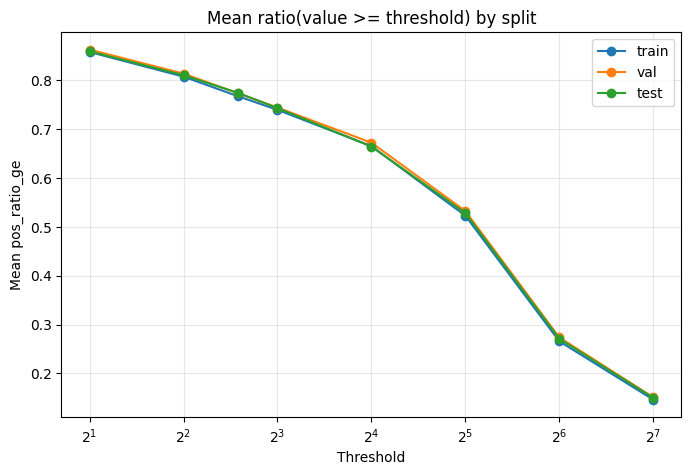

In [3]:
summary = (
    df.groupby(["split", "threshold"], as_index=False)["pos_ratio_ge"]
      .mean()
      .sort_values(["split", "threshold"])
)
display(summary.head(20))

plt.figure(figsize=(8, 5))
for split_name in ["train", "val", "test"]:
    sub = summary[summary["split"] == split_name]
    if len(sub) == 0:
        continue
    plt.plot(sub["threshold"], sub["pos_ratio_ge"], marker="o", label=split_name)
plt.xscale("log", base=2)
plt.xlabel("Threshold")
plt.ylabel("Mean pos_ratio_ge")
plt.title("Mean ratio(value >= threshold) by split")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


## Genus Heatmap

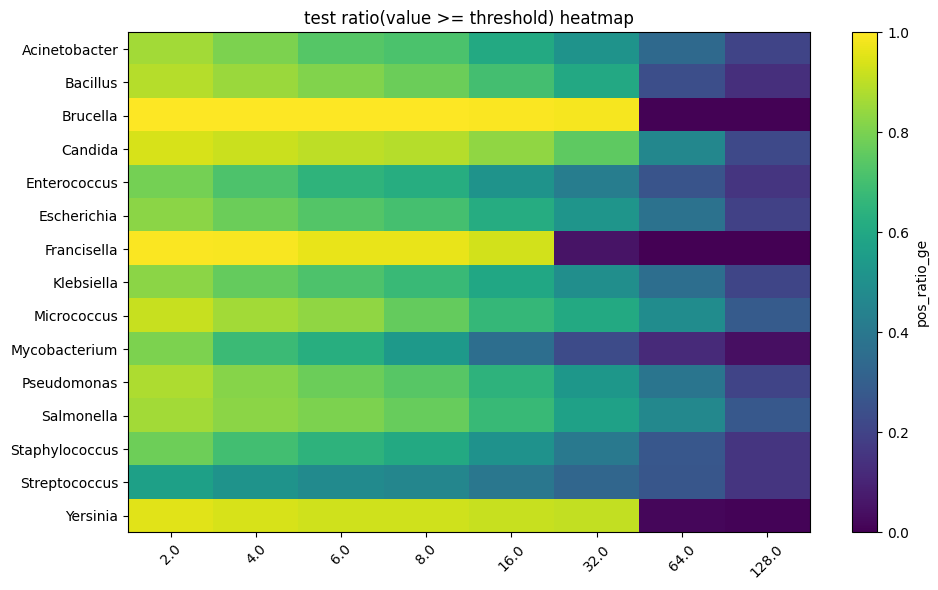

In [4]:
split_name = "test"  # change to train / val / test
sub = df[df["split"] == split_name].copy()
pivot = sub.pivot(index="genus", columns="threshold", values="pos_ratio_ge").sort_index()

plt.figure(figsize=(10, max(6, 0.35 * len(pivot))))
im = plt.imshow(pivot.values, aspect="auto", vmin=0, vmax=1)
plt.colorbar(im, label="pos_ratio_ge")
plt.xticks(range(len(pivot.columns)), [str(c) for c in pivot.columns], rotation=45)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.title(f"{split_name} ratio(value >= threshold) heatmap")
plt.tight_layout()
plt.show()


## Train-Test Shift

In [5]:
# Train-test shift per genus at each threshold
train_df = df[df["split"] == "train"][ ["genus", "threshold", "pos_ratio_ge"] ].rename(columns={"pos_ratio_ge": "train_ratio"})
test_df = df[df["split"] == "test"][ ["genus", "threshold", "pos_ratio_ge"] ].rename(columns={"pos_ratio_ge": "test_ratio"})

shift = train_df.merge(test_df, on=["genus", "threshold"], how="inner")
shift["abs_shift"] = (shift["train_ratio"] - shift["test_ratio"]).abs()
display(shift.sort_values("abs_shift", ascending=False).head(20))


,genus,threshold,train_ratio,test_ratio,abs_shift
29,Candida,32.0,0.609611,0.753156,0.143545
30,Candida,64.0,0.334013,0.464236,0.130223
28,Candida,16.0,0.727118,0.833100,0.105981
69,Micrococcus,32.0,0.515142,0.609223,0.094081
76,Mycobacterium,16.0,0.451224,0.359890,0.091334
66,Micrococcus,6.0,0.753180,0.832524,0.079344
70,Micrococcus,64.0,0.408540,0.485437,0.076897
77,Mycobacterium,32.0,0.305757,0.229396,0.076361
27,Candida,8.0,0.812362,0.887798,0.075436
26,Candida,6.0,0.835626,0.901823,0.066198
